# Base ResNet18

This notebook trains a plain ImageNet-pretrained ResNet18 with no attention mechanism, serving as the baseline anchor for all subsequent SRQ1 comparisons. <br>
Two classifier head options are available: a multi-layer MLP head and a single linear probe. Running both provides a low-cost ablation that isolates whether any downstream performance gains come from backbone or attention improvements rather than head capacity.<br> 
Training follows a standard two-phase protocol:
- Phase 1: trains the classifier head with the backbone frozen
- Phase 2: fine-tunes all parameters at a reduced learning rate. 
<br>
<br>

All results from this notebook form the reference point for comparison against every attention-augmented variant.

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"
IMGS_DIR = ABSOLUTE_PATH / "training-imgs"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)
print(IMGS_DIR)


C:\Users\markm\Workspace\ms-machine-learning-diagnosis
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\training-imgs


In [2]:
import src.scripts.data as data
import src.scripts.models as models
import src.scripts.trainer as trainer
import src.scripts.evaluator as evaluator
import src.scripts.utils as utils

import numpy as np

# Set seed for reproducibility
utils.set_seed(42)
model_name = "resnet18"

Random seed set to 42 for Python, NumPy, and PyTorch


## Data Acquisition & Processing

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


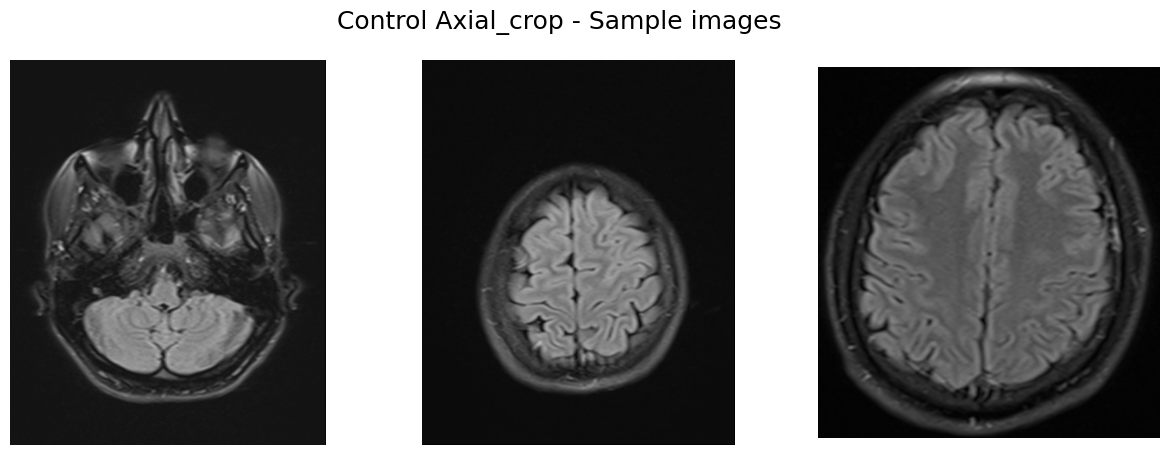

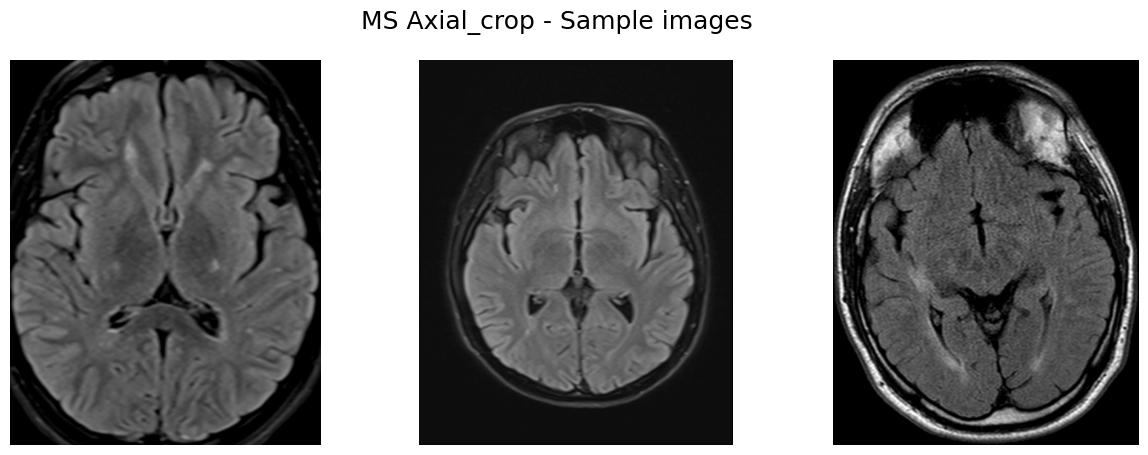

get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201


In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

# Outer split: carve out held-out test set at the start
# X_test / y_test are set aside and not touched until final evaluation.
# All k-fold CV operates exclusively within X_trainval / y_trainval.
X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

N_SPLITS = 5            # number of folds for stratified k-fold
BATCH_SIZE = 32


## Model Instantiation

In [4]:
# Default model is the base ResNet18 architecture
model = models.get_model()

get_model()>>> architecture='base'  head='mlp'


## Model Training

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**Loss & Acc**: Training metrics averaged over an epoch: Loss is mean training loss, Acc is training accuracy for that epoch.<br>

In [ ]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 15,
        "lr": 1e-3,
        "parameters": "head_and_attention",          # train only classifier head (no attention layers in base model)
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 10,
        "lr": 1e-5,                    # lower LR for fine-tuning
        "parameters": "all",           # train backbone + head
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}


  FOLD 1 / 5

get_model()>>> architecture='base'  head='mlp'
get_fold_loaders()>>> Fold 1/5 — Train: 1056,  Val: 265
[base] Epoch 1/15 - Train Loss: 0.5756 - Train Acc: 0.6847 - Val Loss: 0.5143 - Val Acc: 0.7547
[base] Epoch 2/15 - Train Loss: 0.4551 - Train Acc: 0.7907 - Val Loss: 0.4129 - Val Acc: 0.8189
[base] Epoch 3/15 - Train Loss: 0.4197 - Train Acc: 0.8030 - Val Loss: 0.3688 - Val Acc: 0.8377
[base] Epoch 4/15 - Train Loss: 0.3840 - Train Acc: 0.8277 - Val Loss: 0.3982 - Val Acc: 0.8151
[base] Epoch 5/15 - Train Loss: 0.3716 - Train Acc: 0.8324 - Val Loss: 0.3230 - Val Acc: 0.8642
[base] Epoch 6/15 - Train Loss: 0.3604 - Train Acc: 0.8504 - Val Loss: 0.3380 - Val Acc: 0.8377
[base] Epoch 7/15 - Train Loss: 0.3467 - Train Acc: 0.8513 - Val Loss: 0.3068 - Val Acc: 0.8830
[base] Epoch 8/15 - Train Loss: 0.3229 - Train Acc: 0.8475 - Val Loss: 0.3991 - Val Acc: 0.8000
[base] Epoch 9/15 - Train Loss: 0.3498 - Train Acc: 0.8400 - Val Loss: 0.2961 - Val Acc: 0.9057
[base] Epoch 10/15

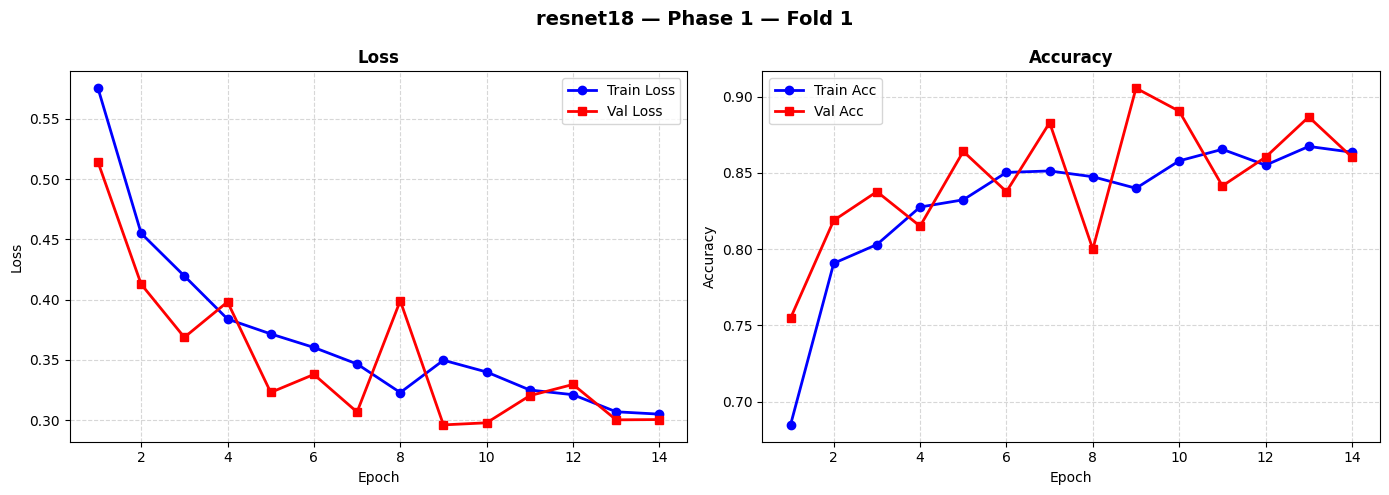

[fine_tune] Epoch 1/10 - Train Loss: 0.2772 - Train Acc: 0.8911 - Val Loss: 0.2611 - Val Acc: 0.9094
[fine_tune] Epoch 2/10 - Train Loss: 0.2300 - Train Acc: 0.9062 - Val Loss: 0.2519 - Val Acc: 0.9094
[fine_tune] Epoch 3/10 - Train Loss: 0.1837 - Train Acc: 0.9280 - Val Loss: 0.2260 - Val Acc: 0.9208
[fine_tune] Epoch 4/10 - Train Loss: 0.1756 - Train Acc: 0.9328 - Val Loss: 0.2140 - Val Acc: 0.9321
[fine_tune] Epoch 5/10 - Train Loss: 0.1596 - Train Acc: 0.9384 - Val Loss: 0.2060 - Val Acc: 0.9321
[fine_tune] Epoch 6/10 - Train Loss: 0.1528 - Train Acc: 0.9384 - Val Loss: 0.1963 - Val Acc: 0.9358
[fine_tune] Epoch 7/10 - Train Loss: 0.1111 - Train Acc: 0.9631 - Val Loss: 0.1890 - Val Acc: 0.9321
[fine_tune] Epoch 8/10 - Train Loss: 0.1044 - Train Acc: 0.9650 - Val Loss: 0.1841 - Val Acc: 0.9396
[fine_tune] Epoch 9/10 - Train Loss: 0.1036 - Train Acc: 0.9602 - Val Loss: 0.1795 - Val Acc: 0.9358
[fine_tune] Epoch 10/10 - Train Loss: 0.0784 - Train Acc: 0.9706 - Val Loss: 0.1743 - Val A

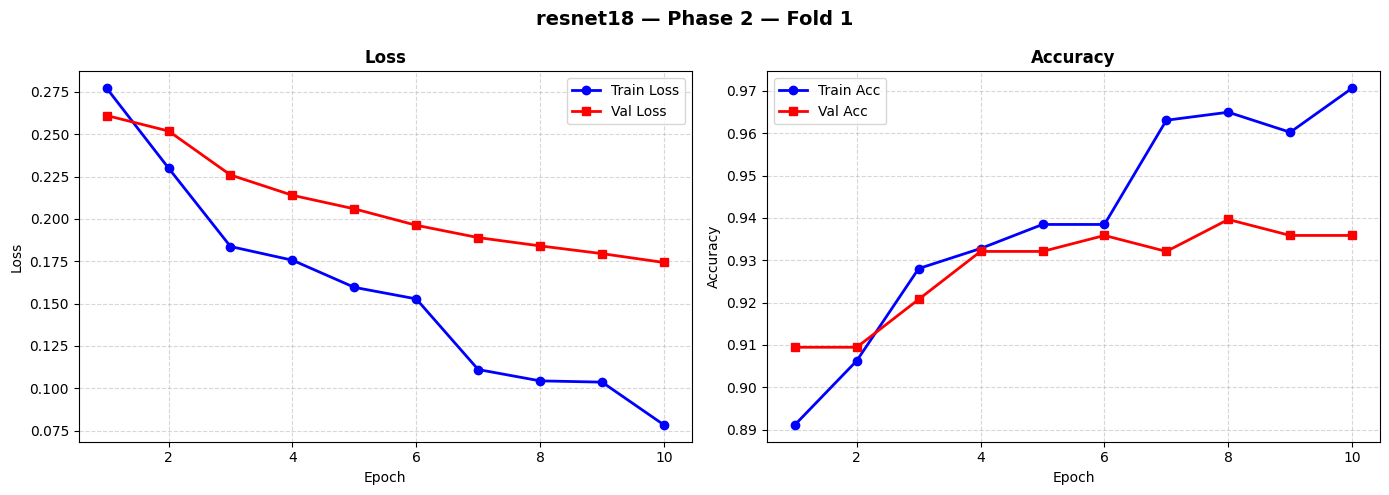

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\resnet18_fold1.pth
Fold 1 complete — Val Acc: 0.9358  Val Loss: 0.1743

  FOLD 2 / 5

get_model()>>> architecture='base'  head='mlp'
get_fold_loaders()>>> Fold 2/5 — Train: 1057,  Val: 264
[base] Epoch 1/15 - Train Loss: 0.5799 - Train Acc: 0.6897 - Val Loss: 0.5369 - Val Acc: 0.6932
[base] Epoch 2/15 - Train Loss: 0.4726 - Train Acc: 0.7682 - Val Loss: 0.4666 - Val Acc: 0.7803
[base] Epoch 3/15 - Train Loss: 0.4785 - Train Acc: 0.7729 - Val Loss: 0.4016 - Val Acc: 0.8068
[base] Epoch 4/15 - Train Loss: 0.4100 - Train Acc: 0.8070 - Val Loss: 0.3932 - Val Acc: 0.8068
[base] Epoch 5/15 - Train Loss: 0.3974 - Train Acc: 0.8136 - Val Loss: 0.4030 - Val Acc: 0.8068
[base] Epoch 6/15 - Train Loss: 0.3786 - Train Acc: 0.8392 - Val Loss: 0.3574 - Val Acc: 0.8447
[base] Epoch 7/15 - Train Loss: 0.3490 - Train Acc: 0.8439 - Val Loss: 0.3493 - Val Acc: 0.8371
[base] Epoch 8/1

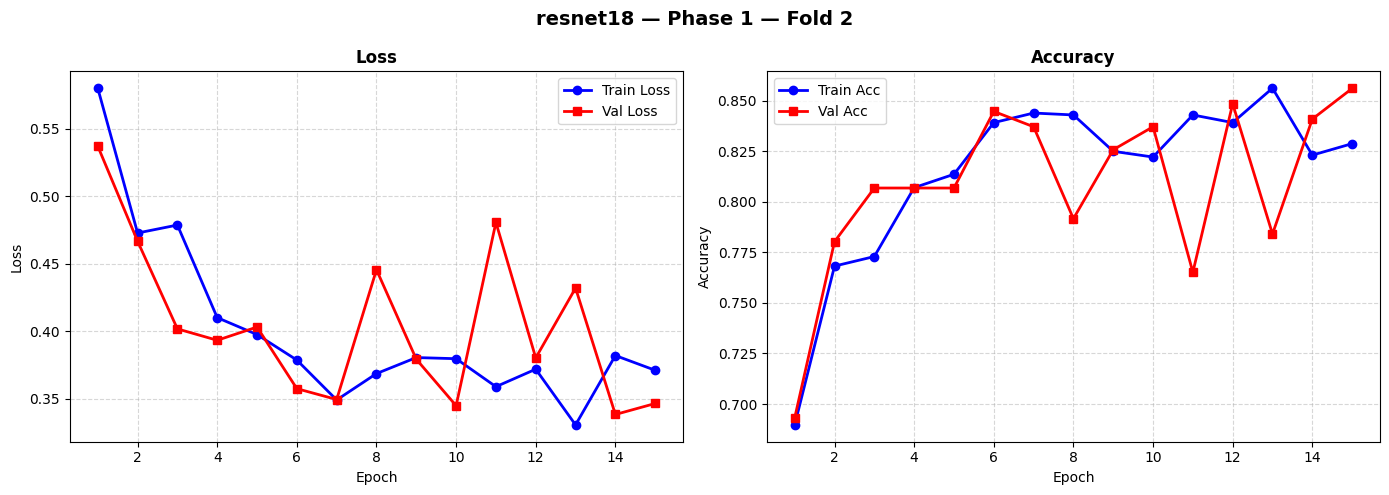

[fine_tune] Epoch 1/10 - Train Loss: 0.2913 - Train Acc: 0.8808 - Val Loss: 0.3156 - Val Acc: 0.8523
[fine_tune] Epoch 2/10 - Train Loss: 0.2516 - Train Acc: 0.8959 - Val Loss: 0.2871 - Val Acc: 0.8485
[fine_tune] Epoch 3/10 - Train Loss: 0.2210 - Train Acc: 0.9111 - Val Loss: 0.2545 - Val Acc: 0.8674
[fine_tune] Epoch 4/10 - Train Loss: 0.1777 - Train Acc: 0.9395 - Val Loss: 0.2458 - Val Acc: 0.8864
[fine_tune] Epoch 5/10 - Train Loss: 0.1511 - Train Acc: 0.9461 - Val Loss: 0.2403 - Val Acc: 0.8712
[fine_tune] Epoch 6/10 - Train Loss: 0.1485 - Train Acc: 0.9499 - Val Loss: 0.2162 - Val Acc: 0.8977
[fine_tune] Epoch 7/10 - Train Loss: 0.1422 - Train Acc: 0.9518 - Val Loss: 0.2712 - Val Acc: 0.8939
[fine_tune] Epoch 8/10 - Train Loss: 0.1069 - Train Acc: 0.9640 - Val Loss: 0.2143 - Val Acc: 0.8939
[fine_tune] Epoch 9/10 - Train Loss: 0.1051 - Train Acc: 0.9640 - Val Loss: 0.2208 - Val Acc: 0.9091
[fine_tune] Epoch 10/10 - Train Loss: 0.1012 - Train Acc: 0.9640 - Val Loss: 0.1939 - Val A

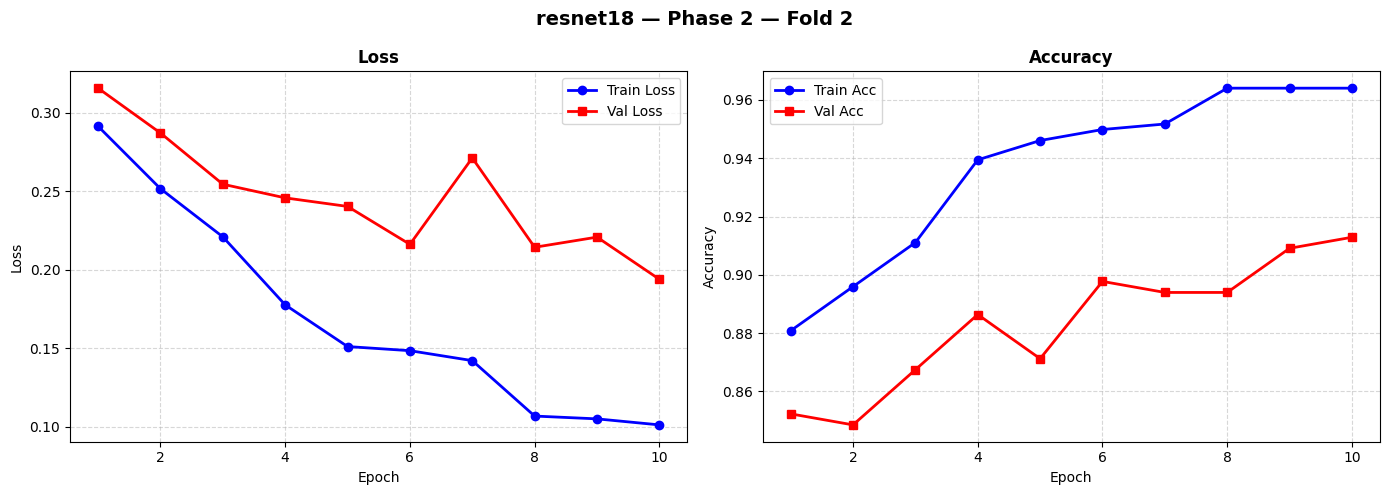

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\resnet18_fold2.pth
Fold 2 complete — Val Acc: 0.9129  Val Loss: 0.1939

  FOLD 3 / 5

get_model()>>> architecture='base'  head='mlp'
get_fold_loaders()>>> Fold 3/5 — Train: 1057,  Val: 264
[base] Epoch 1/15 - Train Loss: 0.5781 - Train Acc: 0.7133 - Val Loss: 0.6431 - Val Acc: 0.6591
[base] Epoch 2/15 - Train Loss: 0.4896 - Train Acc: 0.7578 - Val Loss: 0.4868 - Val Acc: 0.7879
[base] Epoch 3/15 - Train Loss: 0.4368 - Train Acc: 0.8042 - Val Loss: 0.4352 - Val Acc: 0.7803
[base] Epoch 4/15 - Train Loss: 0.4268 - Train Acc: 0.7975 - Val Loss: 0.4464 - Val Acc: 0.8030
[base] Epoch 5/15 - Train Loss: 0.4217 - Train Acc: 0.8042 - Val Loss: 0.4224 - Val Acc: 0.7803
[base] Epoch 6/15 - Train Loss: 0.3987 - Train Acc: 0.8155 - Val Loss: 0.3984 - Val Acc: 0.8447
[base] Epoch 7/15 - Train Loss: 0.3934 - Train Acc: 0.8117 - Val Loss: 0.4308 - Val Acc: 0.8182
[base] Epoch 8/1

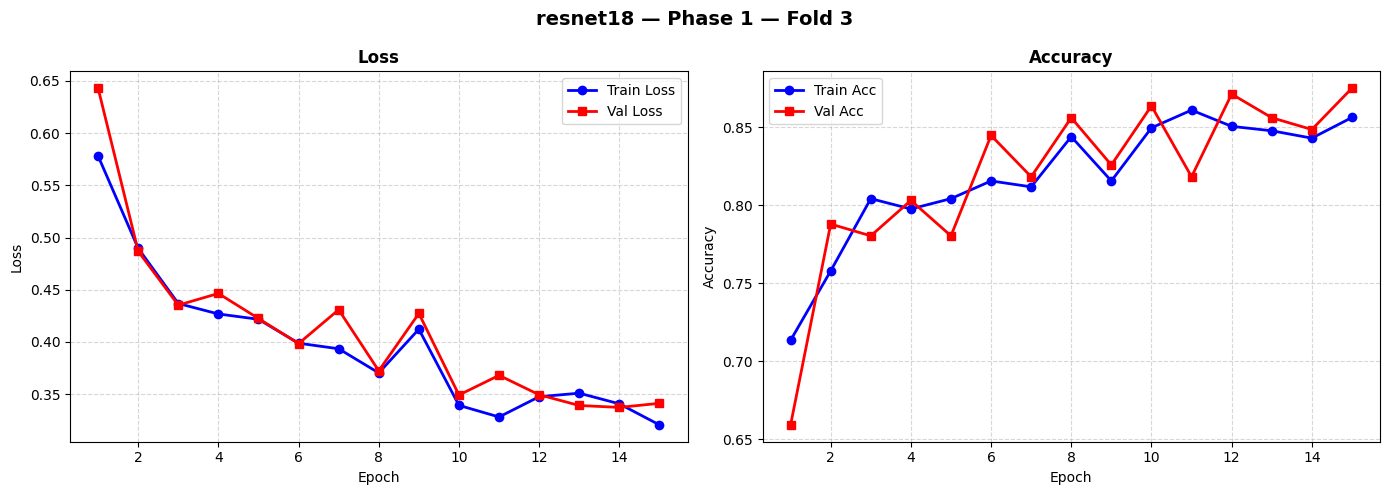

[fine_tune] Epoch 1/10 - Train Loss: 0.3052 - Train Acc: 0.8713 - Val Loss: 0.2996 - Val Acc: 0.8826
[fine_tune] Epoch 2/10 - Train Loss: 0.2499 - Train Acc: 0.8950 - Val Loss: 0.2526 - Val Acc: 0.8939
[fine_tune] Epoch 3/10 - Train Loss: 0.1978 - Train Acc: 0.9234 - Val Loss: 0.2316 - Val Acc: 0.9167
[fine_tune] Epoch 4/10 - Train Loss: 0.1892 - Train Acc: 0.9272 - Val Loss: 0.2106 - Val Acc: 0.9280
[fine_tune] Epoch 5/10 - Train Loss: 0.1692 - Train Acc: 0.9357 - Val Loss: 0.1987 - Val Acc: 0.9318
[fine_tune] Epoch 6/10 - Train Loss: 0.1478 - Train Acc: 0.9518 - Val Loss: 0.1963 - Val Acc: 0.9432
[fine_tune] Epoch 7/10 - Train Loss: 0.1430 - Train Acc: 0.9480 - Val Loss: 0.1874 - Val Acc: 0.9394
[fine_tune] Epoch 8/10 - Train Loss: 0.1303 - Train Acc: 0.9546 - Val Loss: 0.1868 - Val Acc: 0.9394
[fine_tune] Epoch 9/10 - Train Loss: 0.1073 - Train Acc: 0.9716 - Val Loss: 0.1861 - Val Acc: 0.9432
[fine_tune] Epoch 10/10 - Train Loss: 0.0924 - Train Acc: 0.9688 - Val Loss: 0.2064 - Val A

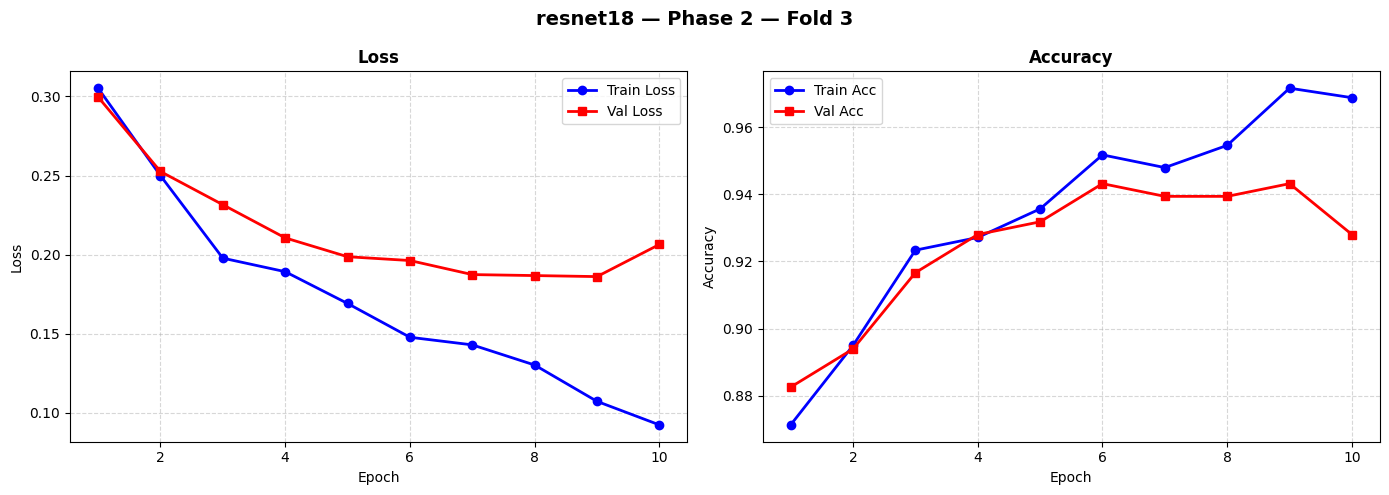

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\resnet18_fold3.pth
Fold 3 complete — Val Acc: 0.9280  Val Loss: 0.2064

  FOLD 4 / 5

get_model()>>> architecture='base'  head='mlp'
get_fold_loaders()>>> Fold 4/5 — Train: 1057,  Val: 264
[base] Epoch 1/15 - Train Loss: 0.5579 - Train Acc: 0.7039 - Val Loss: 0.5599 - Val Acc: 0.7197
[base] Epoch 2/15 - Train Loss: 0.4402 - Train Acc: 0.7815 - Val Loss: 0.4307 - Val Acc: 0.8030
[base] Epoch 3/15 - Train Loss: 0.4322 - Train Acc: 0.8042 - Val Loss: 0.6524 - Val Acc: 0.7311
[base] Epoch 4/15 - Train Loss: 0.4347 - Train Acc: 0.7994 - Val Loss: 0.4069 - Val Acc: 0.8220
[base] Epoch 5/15 - Train Loss: 0.3838 - Train Acc: 0.8307 - Val Loss: 0.3854 - Val Acc: 0.8447
[base] Epoch 6/15 - Train Loss: 0.3558 - Train Acc: 0.8316 - Val Loss: 0.4066 - Val Acc: 0.8144
[base] Epoch 7/15 - Train Loss: 0.3774 - Train Acc: 0.8240 - Val Loss: 0.3731 - Val Acc: 0.8447
[base] Epoch 8/1

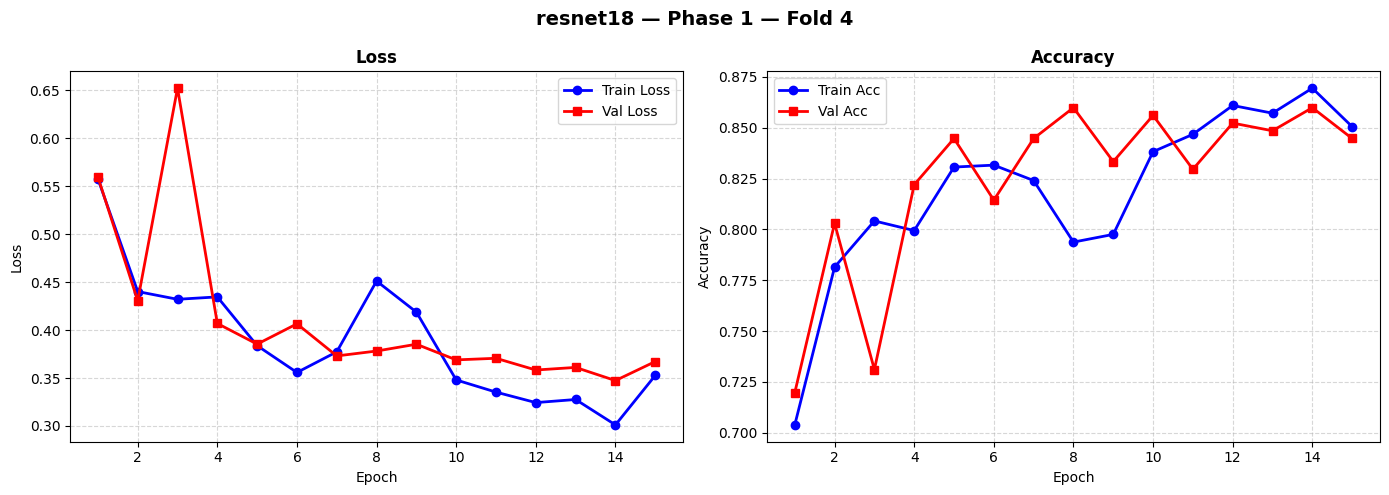

[fine_tune] Epoch 1/10 - Train Loss: 0.2970 - Train Acc: 0.8685 - Val Loss: 0.3238 - Val Acc: 0.8674
[fine_tune] Epoch 2/10 - Train Loss: 0.2456 - Train Acc: 0.8969 - Val Loss: 0.2881 - Val Acc: 0.8902
[fine_tune] Epoch 3/10 - Train Loss: 0.2012 - Train Acc: 0.9224 - Val Loss: 0.2660 - Val Acc: 0.8826
[fine_tune] Epoch 4/10 - Train Loss: 0.1763 - Train Acc: 0.9395 - Val Loss: 0.2601 - Val Acc: 0.8788
[fine_tune] Epoch 5/10 - Train Loss: 0.1676 - Train Acc: 0.9328 - Val Loss: 0.2565 - Val Acc: 0.8939
[fine_tune] Epoch 6/10 - Train Loss: 0.1458 - Train Acc: 0.9432 - Val Loss: 0.2521 - Val Acc: 0.9129
[fine_tune] Epoch 7/10 - Train Loss: 0.1231 - Train Acc: 0.9565 - Val Loss: 0.2905 - Val Acc: 0.9015
[fine_tune] Epoch 8/10 - Train Loss: 0.1035 - Train Acc: 0.9640 - Val Loss: 0.2357 - Val Acc: 0.8977
[fine_tune] Epoch 9/10 - Train Loss: 0.1032 - Train Acc: 0.9603 - Val Loss: 0.2368 - Val Acc: 0.9167
[fine_tune] Epoch 10/10 - Train Loss: 0.0739 - Train Acc: 0.9792 - Val Loss: 0.2336 - Val A

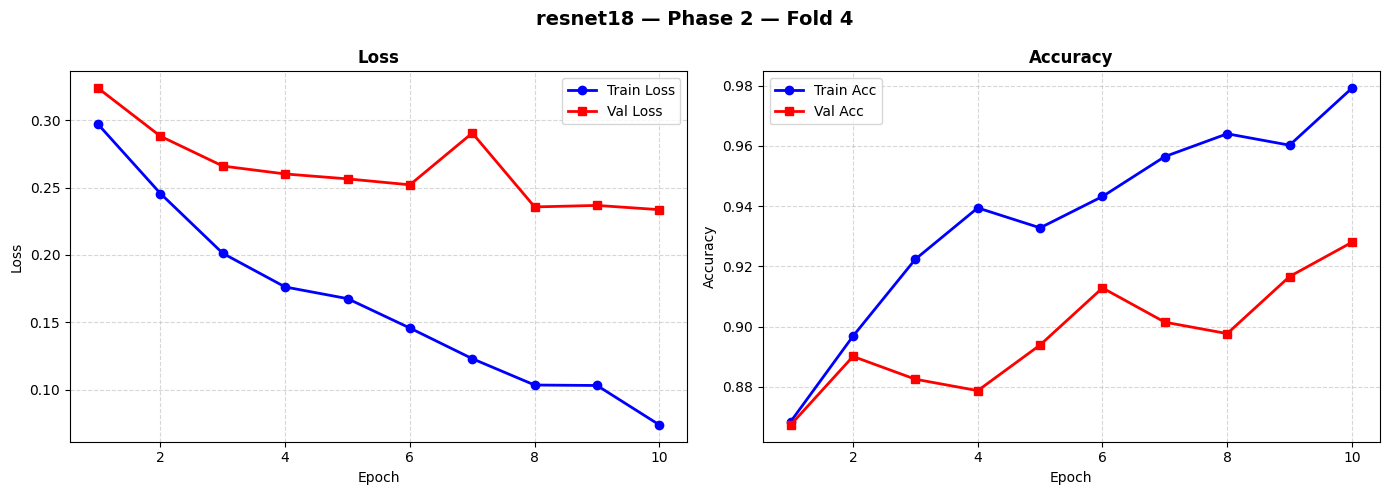

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\resnet18_fold4.pth
Fold 4 complete — Val Acc: 0.9280  Val Loss: 0.2336

  FOLD 5 / 5

get_model()>>> architecture='base'  head='mlp'
get_fold_loaders()>>> Fold 5/5 — Train: 1057,  Val: 264
[base] Epoch 1/15 - Train Loss: 0.5310 - Train Acc: 0.7304 - Val Loss: 0.6889 - Val Acc: 0.6553
[base] Epoch 2/15 - Train Loss: 0.4393 - Train Acc: 0.7985 - Val Loss: 0.4298 - Val Acc: 0.7992
[base] Epoch 3/15 - Train Loss: 0.4083 - Train Acc: 0.8098 - Val Loss: 0.4035 - Val Acc: 0.8371
[base] Epoch 4/15 - Train Loss: 0.3854 - Train Acc: 0.8278 - Val Loss: 0.4590 - Val Acc: 0.7955
[base] Epoch 5/15 - Train Loss: 0.3978 - Train Acc: 0.8155 - Val Loss: 0.4168 - Val Acc: 0.8182
[base] Epoch 6/15 - Train Loss: 0.3825 - Train Acc: 0.8269 - Val Loss: 0.3857 - Val Acc: 0.8182
[base] Epoch 7/15 - Train Loss: 0.3629 - Train Acc: 0.8193 - Val Loss: 0.3791 - Val Acc: 0.8068
[base] Epoch 8/1

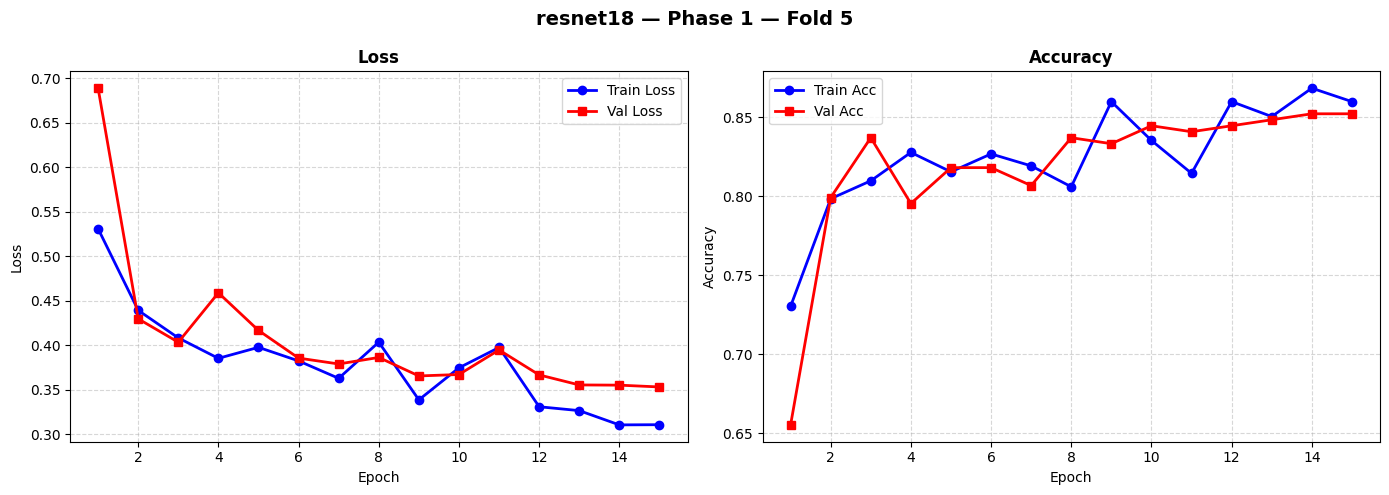

[fine_tune] Epoch 1/10 - Train Loss: 0.3013 - Train Acc: 0.8723 - Val Loss: 0.3037 - Val Acc: 0.8750
[fine_tune] Epoch 2/10 - Train Loss: 0.2427 - Train Acc: 0.8997 - Val Loss: 0.2841 - Val Acc: 0.8864
[fine_tune] Epoch 3/10 - Train Loss: 0.2172 - Train Acc: 0.9149 - Val Loss: 0.2551 - Val Acc: 0.8902
[fine_tune] Epoch 4/10 - Train Loss: 0.1904 - Train Acc: 0.9290 - Val Loss: 0.2358 - Val Acc: 0.8977
[fine_tune] Epoch 5/10 - Train Loss: 0.1466 - Train Acc: 0.9518 - Val Loss: 0.2199 - Val Acc: 0.9053
[fine_tune] Epoch 6/10 - Train Loss: 0.1392 - Train Acc: 0.9527 - Val Loss: 0.2107 - Val Acc: 0.9129
[fine_tune] Epoch 7/10 - Train Loss: 0.1264 - Train Acc: 0.9555 - Val Loss: 0.1963 - Val Acc: 0.9205
[fine_tune] Epoch 8/10 - Train Loss: 0.1233 - Train Acc: 0.9565 - Val Loss: 0.1949 - Val Acc: 0.9167
[fine_tune] Epoch 9/10 - Train Loss: 0.1084 - Train Acc: 0.9678 - Val Loss: 0.1849 - Val Acc: 0.9129
[fine_tune] Epoch 10/10 - Train Loss: 0.0944 - Train Acc: 0.9688 - Val Loss: 0.1828 - Val A

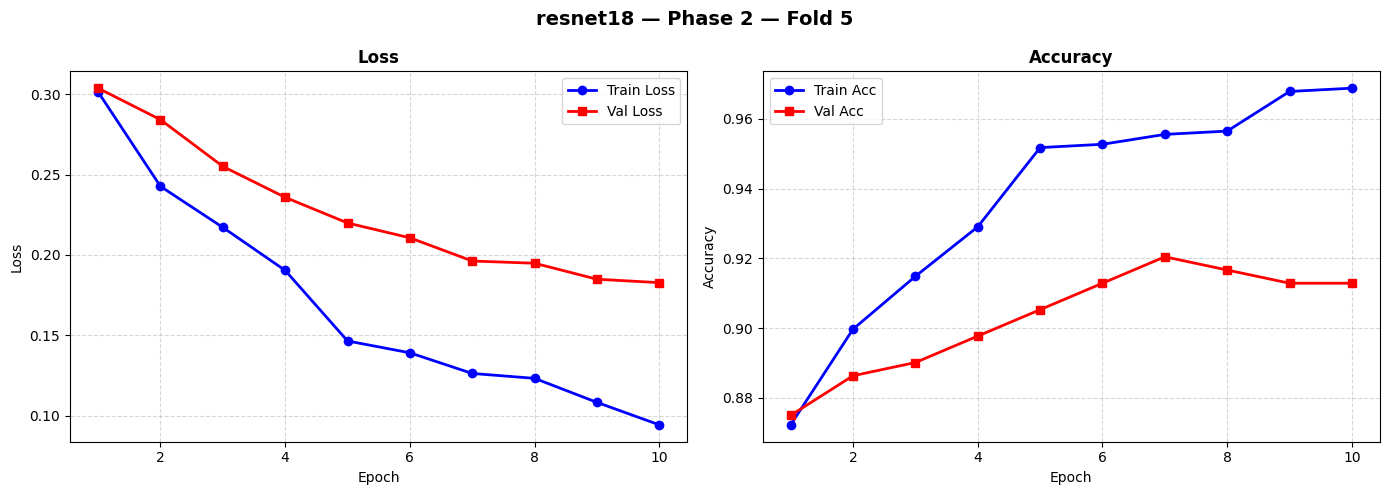

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\resnet18_fold5.pth
Fold 5 complete — Val Acc: 0.9129  Val Loss: 0.1828

K-FOLD RESULTS (5 folds)
  Fold 1: Val Acc = 0.9358   Val Loss = 0.1743
  Fold 2: Val Acc = 0.9129   Val Loss = 0.1939
  Fold 3: Val Acc = 0.9280   Val Loss = 0.2064
  Fold 4: Val Acc = 0.9280   Val Loss = 0.2336
  Fold 5: Val Acc = 0.9129   Val Loss = 0.1828
  Mean Val Acc  : 0.9235 +/- 0.0092
  Mean Val Loss : 0.1982 +/- 0.0207


In [6]:
# Storage for results across folds
fold_val_accs  = []   # final val accuracy per fold (end of Phase 2)
fold_val_losses = []  # final val loss per fold

for fold_idx in range(N_SPLITS):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx+1} / {N_SPLITS}")
    print(f"{'='*60}\n")

    # Fresh model for each fold
    model = models.get_model()

    # Get train/val loaders for this fold
    train_loader, val_loader = data.get_fold_loaders(
        X_trainval, y_trainval,
        fold_idx=fold_idx,
        train_transform=train_transform,
        test_transform=test_transform,
        n_splits=N_SPLITS,
        batch_size=BATCH_SIZE,
        SEED=42
    )

    # Phase 1 
    losses_p1, accs_p1, val_losses_p1, val_accs_p1 = trainer.train_model(
        model, train_loader, val_loader,
        config_name="base",
        train_configs=train_configs,
        early_stopping_patience=5
    )
    utils.plot(
        losses_p1, accs_p1,
        config_name=f"Phase 1 — Fold {fold_idx+1}",
        val_losses=val_losses_p1, val_accuracies=val_accs_p1,
        model_name=model_name, save_dir=str(IMGS_DIR)
    )

    # Phase 2
    losses_p2, accs_p2, val_losses_p2, val_accs_p2 = trainer.train_model(
        model, train_loader, val_loader,
        config_name="fine_tune",
        train_configs=train_configs,
        early_stopping_patience=5
    )
    utils.plot(
        losses_p2, accs_p2,
        config_name=f"Phase 2 — Fold {fold_idx+1}",
        val_losses=val_losses_p2, val_accuracies=val_accs_p2,
        model_name=model_name, save_dir=str(IMGS_DIR)
    )

    # Save weights for this fold
    utils.save_weights(model, WEIGHTS_DIR / f"{model_name}_fold{fold_idx+1}.pth")

    # Record fold result 
    fold_val_accs.append(val_accs_p2[-1])
    fold_val_losses.append(val_losses_p2[-1])
    print(f"Fold {fold_idx+1} complete — Val Acc: {val_accs_p2[-1]:.4f}  Val Loss: {val_losses_p2[-1]:.4f}")

# Summary across all folds
print(f"\n{'='*60}")
print(f"K-FOLD RESULTS ({N_SPLITS} folds)")
print(f"{'='*60}")
for i, (acc, loss) in enumerate(zip(fold_val_accs, fold_val_losses)):
    print(f"  Fold {i+1}: Val Acc = {acc:.4f}   Val Loss = {loss:.4f}")
print(f"  Mean Val Acc  : {np.mean(fold_val_accs):.4f} +/- {np.std(fold_val_accs):.4f}")
print(f"  Mean Val Loss : {np.mean(fold_val_losses):.4f} +/- {np.std(fold_val_losses):.4f}")


## Load Saved Weights
Option to load weights from previous training

In [7]:
# Load weights from a specific fold for inspection or evaluation
FOLD_TO_LOAD = 1

# Loads best fold weights based on val accuracy, uncomment to use but requires training data vars
# best_fold = int(np.argmax(fold_val_accs)) + 1
# print(f"Best fold by val accuracy: Fold {best_fold} ({max(fold_val_accs):.4f})")
# FOLD_TO_LOAD = best_fold

model = models.get_model(architecture="base")
model = utils.load_weights(model, WEIGHTS_DIR / f"{model_name}_fold{FOLD_TO_LOAD}.pth")

get_model()>>> architecture='base'  head='mlp'
load_weights()>>> Model loaded successfully and set to evaluation mode.


## Model Evaluation
**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

In [8]:
# Final evaluation on held-out test set

# Build test loader and evaluate
test_loader = data.get_test_loader(X_test, y_test, test_transform, batch_size=BATCH_SIZE)

acc, prec, rec, f1, auc, ece, conf, report = evaluator.evaluate_model(model, test_loader)


get_test_loader()>>> Test loader ready — 331 samples
Accuracy  : 0.9245
Precision : 0.9339
Recall    : 0.8692
F1        : 0.9004
AUC-ROC   : 0.9750
ECE       : 0.0301  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[193   8]
 [ 17 113]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       201
           1       0.93      0.87      0.90       130

    accuracy                           0.92       331
   macro avg       0.93      0.91      0.92       331
weighted avg       0.92      0.92      0.92       331



## Model Prediction Visualisation

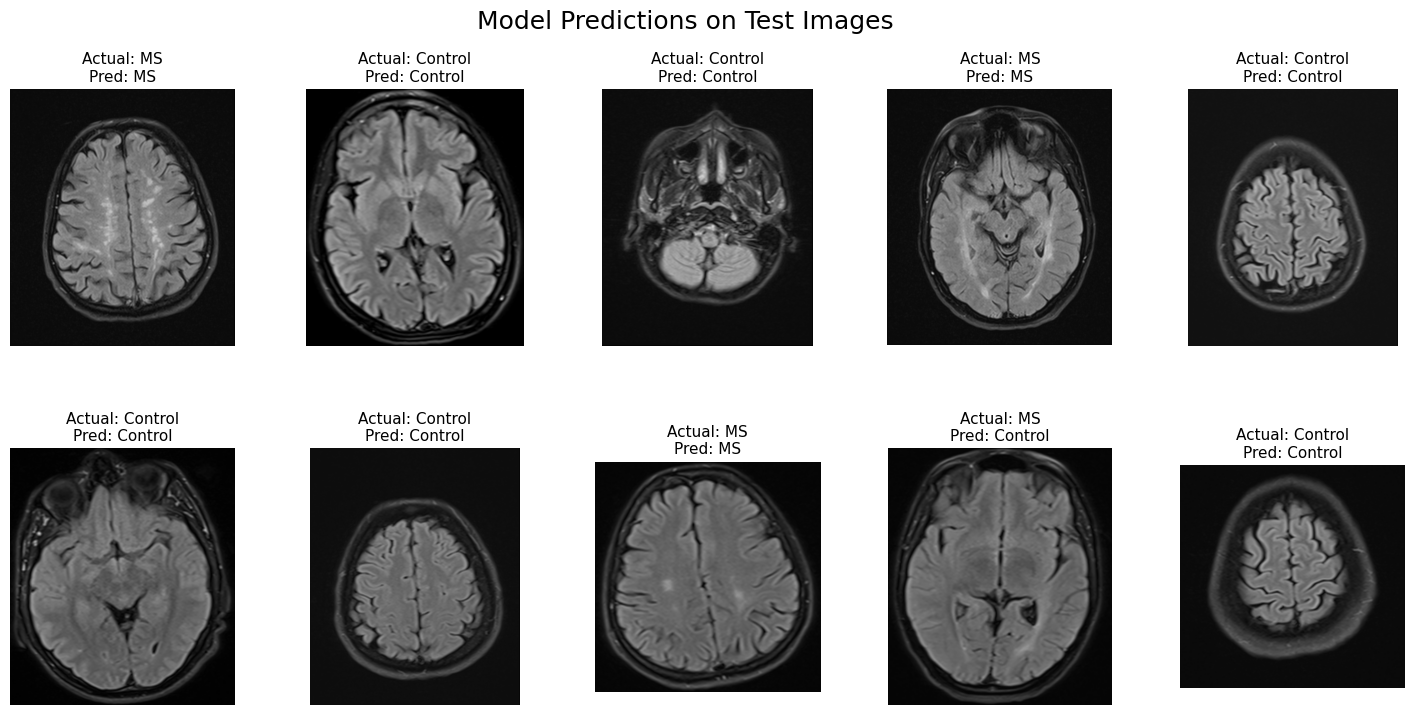

In [9]:
evaluator.predict_model(model, X_test, y_test, test_transform)
